# Group 6 – Model and Data Monitoring

## RF Intrusion Detection MLOps Pipeline

This notebook implements model and data monitoring for the Group 6 RF Intrusion Detection system deployed through Amazon SageMaker Batch Transform.

The monitoring workflow builds on the existing SageMaker deployment and establishes monitoring capabilities for:

1. Model performance and prediction behavior
2. Prediction confidence
3. Class prediction distribution
4. Data quality and distribution changes
5. Detection of potential model and data drift

The monitoring results will support continued evaluation of the deployed RF intrusion detection model and provide inputs for later CloudWatch monitoring and reporting activities.

# Part 1: Model Monitoring

The deployed CNN model is monitored against previously established baseline performance metrics. The baseline represents expected model behavior and provides reference values for identifying potential degradation or changes in prediction behavior during future batch inference runs.

The model monitoring process evaluates accuracy, F1-score, prediction confidence, low-confidence prediction rate, and predicted class distribution.

In [1]:
import json
import os
import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# AWS configuration
aws_session = boto3.Session()
region = aws_session.region_name

# S3 client
s3 = boto3.client("s3")

print("AWS Region:", region)
print("AWS configuration loaded successfully.")

AWS Region: us-east-1
AWS configuration loaded successfully.


## Load Model Monitoring Baseline

The baseline metrics generated during model evaluation are loaded as the reference for monitoring subsequent batch predictions. These values represent the expected performance and prediction behavior of model version v1.

In [2]:
BASELINE_PATH = "monitoring_baseline.json"

with open(BASELINE_PATH, "r") as f:
    model_baseline = json.load(f)

print("Model Monitoring Baseline")
print("=" * 50)

for key, value in model_baseline.items():
    if key != "predicted_class_distribution":
        print(f"{key}: {value}")

print("\nPredicted Class Distribution")
print("=" * 50)

for class_name, count in model_baseline["predicted_class_distribution"].items():
    print(f"{class_name}: {count}")

Model Monitoring Baseline
model_version: v1
test_accuracy: 0.8361111283302307
test_loss: 0.34248679876327515
macro_f1: 0.829
mean_prediction_confidence: 0.8241221904754639
median_prediction_confidence: 0.8929953575134277
low_confidence_threshold: 0.6
low_confidence_rate: 0.13666666666666666

Predicted Class Distribution
Benign: 809
Broadband_Jam: 600
Human: 567
Machine: 392
Narrowband_Jam: 601
Wildlife: 631


## Model Monitoring Thresholds

Monitoring thresholds are defined relative to the established model baseline. These thresholds provide operational criteria for identifying potential degradation in model performance or prediction behavior.

The following conditions are monitored:

- Accuracy degradation greater than 5 percentage points from baseline
- Macro F1 degradation greater than 5 percentage points from baseline
- Mean prediction confidence below 75%
- Low-confidence prediction rate above 20%
- Significant changes in predicted class distribution

These thresholds provide an initial monitoring framework and can be refined as additional production batch results become available.

In [3]:
# Model monitoring thresholds

monitoring_thresholds = {
    "minimum_accuracy": model_baseline["test_accuracy"] - 0.05,
    "minimum_macro_f1": model_baseline["macro_f1"] - 0.05,
    "minimum_mean_confidence": 0.75,
    "maximum_low_confidence_rate": 0.20
}

print("Model Monitoring Thresholds")
print("=" * 50)

print(
    f"Minimum Accuracy: "
    f"{monitoring_thresholds['minimum_accuracy']:.3f}"
)

print(
    f"Minimum Macro F1: "
    f"{monitoring_thresholds['minimum_macro_f1']:.3f}"
)

print(
    f"Minimum Mean Confidence: "
    f"{monitoring_thresholds['minimum_mean_confidence']:.2f}"
)

print(
    f"Maximum Low-Confidence Rate: "
    f"{monitoring_thresholds['maximum_low_confidence_rate']:.2f}"
)

Model Monitoring Thresholds
Minimum Accuracy: 0.786
Minimum Macro F1: 0.779
Minimum Mean Confidence: 0.75
Maximum Low-Confidence Rate: 0.20


## Model Performance Monitor

A reusable monitoring function compares metrics from a new batch inference run against the established monitoring thresholds. Each monitored metric is assigned a PASS or ALERT status, allowing potential model degradation to be identified consistently across future batch inference runs.

In [4]:
def monitor_model_performance(
    accuracy,
    macro_f1,
    mean_confidence,
    low_confidence_rate
):
    """
    Compare current batch model metrics against
    established monitoring thresholds.
    """

    results = {
        "Accuracy": {
            "value": accuracy,
            "threshold": monitoring_thresholds["minimum_accuracy"],
            "status": (
                "PASS"
                if accuracy >= monitoring_thresholds["minimum_accuracy"]
                else "ALERT"
            )
        },

        "Macro F1": {
            "value": macro_f1,
            "threshold": monitoring_thresholds["minimum_macro_f1"],
            "status": (
                "PASS"
                if macro_f1 >= monitoring_thresholds["minimum_macro_f1"]
                else "ALERT"
            )
        },

        "Mean Confidence": {
            "value": mean_confidence,
            "threshold": monitoring_thresholds["minimum_mean_confidence"],
            "status": (
                "PASS"
                if mean_confidence >= monitoring_thresholds["minimum_mean_confidence"]
                else "ALERT"
            )
        },

        "Low Confidence Rate": {
            "value": low_confidence_rate,
            "threshold": monitoring_thresholds["maximum_low_confidence_rate"],
            "status": (
                "PASS"
                if low_confidence_rate <=
                monitoring_thresholds["maximum_low_confidence_rate"]
                else "ALERT"
            )
        }
    }

    return pd.DataFrame(results).T

### Baseline Monitoring Validation

The monitoring function is first validated using the established model baseline. Because these metrics represent expected model behavior, all monitoring checks should return a PASS status.

In [5]:
baseline_monitor_results = monitor_model_performance(
    accuracy=model_baseline["test_accuracy"],
    macro_f1=model_baseline["macro_f1"],
    mean_confidence=model_baseline["mean_prediction_confidence"],
    low_confidence_rate=model_baseline["low_confidence_rate"]
)

baseline_monitor_results

,value,threshold,status
Accuracy,0.836111,0.786111,PASS
Macro F1,0.829,0.779,PASS
Mean Confidence,0.824122,0.75,PASS
Low Confidence Rate,0.136667,0.2,PASS


### Model Degradation Test

A simulated degraded batch is used to validate that the monitoring logic can identify model performance problems. The simulated metrics intentionally fall outside the established thresholds. This test does not represent actual production performance; it verifies that the monitoring logic correctly generates alerts when model behavior deteriorates.

In [6]:
degraded_monitor_results = monitor_model_performance(
    accuracy=0.74,
    macro_f1=0.72,
    mean_confidence=0.68,
    low_confidence_rate=0.27
)

degraded_monitor_results

,value,threshold,status
Accuracy,0.74,0.786111,ALERT
Macro F1,0.72,0.779,ALERT
Mean Confidence,0.68,0.75,ALERT
Low Confidence Rate,0.27,0.2,ALERT


In [7]:
def get_overall_model_status(results_df):
    """
    Return an overall monitoring status based on
    individual metric checks.
    """

    if (results_df["status"] == "ALERT").any():
        return "ALERT"
    else:
        return "PASS"


baseline_status = get_overall_model_status(
    baseline_monitor_results
)

degraded_status = get_overall_model_status(
    degraded_monitor_results
)

print("Baseline Model Status:", baseline_status)
print("Simulated Degraded Model Status:", degraded_status)

Baseline Model Status: PASS
Simulated Degraded Model Status: ALERT


## Predicted Class Distribution Monitoring

Changes in predicted class distribution can indicate shifts in incoming RF activity or changes in model behavior. Because batch sizes may vary, class counts are converted to proportions before comparison.

The baseline predicted class distribution is used as the reference distribution for future batch inference runs.

In [8]:
baseline_class_counts = pd.Series(
    model_baseline["predicted_class_distribution"],
    dtype=float
)

baseline_class_distribution = (
    baseline_class_counts / baseline_class_counts.sum()
)

baseline_class_df = pd.DataFrame({
    "Count": baseline_class_counts.astype(int),
    "Proportion": baseline_class_distribution
})

baseline_class_df

,Count,Proportion
Benign,809,0.224722
Broadband_Jam,600,0.166667
Human,567,0.157500
Machine,392,0.108889
Narrowband_Jam,601,0.166944
Wildlife,631,0.175278


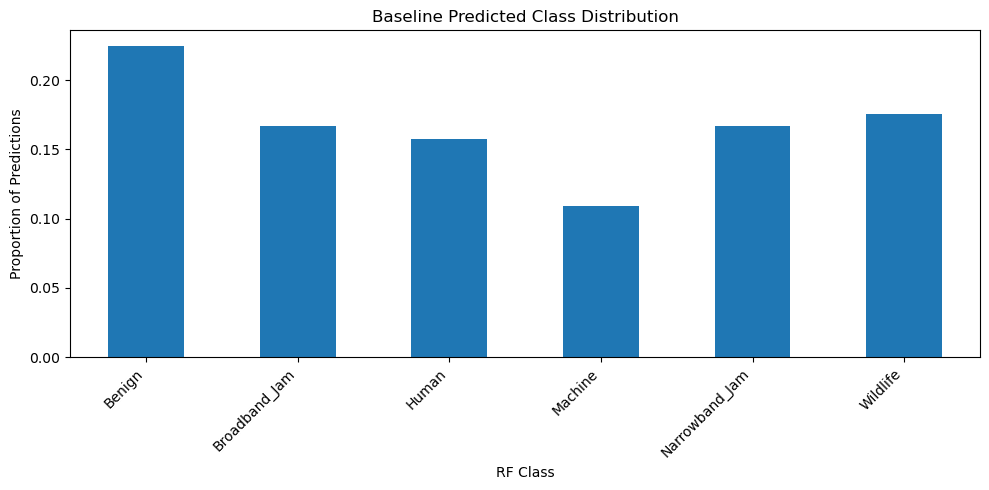

In [9]:
plt.figure(figsize=(10, 5))

baseline_class_distribution.plot(kind="bar")

plt.title("Baseline Predicted Class Distribution")
plt.xlabel("RF Class")
plt.ylabel("Proportion of Predictions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Class Distribution Drift Detection

Predicted class distributions are compared with the established baseline to identify changes in model prediction behavior. Because batch sizes may vary, normalized class proportions are compared rather than raw prediction counts.

For this monitoring implementation, a change greater than 5 percentage points for any individual class is treated as a potential class-distribution drift alert.

In [10]:
CLASS_DRIFT_THRESHOLD = 0.05

def monitor_class_distribution(current_counts):
    """
    Compare the predicted class distribution from a new batch
    against the established baseline distribution.
    """

    current_counts = pd.Series(current_counts, dtype=float)

    # Ensure the same class order as the baseline
    current_counts = current_counts.reindex(
        baseline_class_distribution.index,
        fill_value=0
    )

    # Convert counts to proportions
    current_distribution = (
        current_counts / current_counts.sum()
    )

    comparison = pd.DataFrame({
        "Baseline Proportion": baseline_class_distribution,
        "Current Proportion": current_distribution
    })

    comparison["Absolute Change"] = (
        comparison["Current Proportion"]
        - comparison["Baseline Proportion"]
    ).abs()

    comparison["Status"] = np.where(
        comparison["Absolute Change"] > CLASS_DRIFT_THRESHOLD,
        "ALERT",
        "PASS"
    )

    return comparison

### Baseline Distribution Validation

The established baseline class counts are first passed through the class-distribution monitor. Because the current distribution is identical to the reference distribution, all classes should return a PASS status.

In [11]:
baseline_distribution_results = monitor_class_distribution(
    model_baseline["predicted_class_distribution"]
)

baseline_distribution_results

,Baseline Proportion,Current Proportion,Absolute Change,Status
Benign,0.224722,0.224722,0.0,PASS
Broadband_Jam,0.166667,0.166667,0.0,PASS
Human,0.157500,0.157500,0.0,PASS
Machine,0.108889,0.108889,0.0,PASS
Narrowband_Jam,0.166944,0.166944,0.0,PASS
Wildlife,0.175278,0.175278,0.0,PASS


### Simulated Class Distribution Drift

A simulated prediction batch is used to validate the class-distribution monitoring logic. The simulated batch intentionally changes the relative frequency of several predicted classes. This test demonstrates whether the monitoring system can identify prediction-distribution changes that exceed the defined threshold.

In [12]:
simulated_drift_counts = {
    "Benign": 1400,
    "Broadband_Jam": 400,
    "Human": 450,
    "Machine": 300,
    "Narrowband_Jam": 450,
    "Wildlife": 600
}

drift_distribution_results = monitor_class_distribution(
    simulated_drift_counts
)

drift_distribution_results

,Baseline Proportion,Current Proportion,Absolute Change,Status
Benign,0.224722,0.388889,0.164167,ALERT
Broadband_Jam,0.166667,0.111111,0.055556,ALERT
Human,0.157500,0.125000,0.032500,PASS
Machine,0.108889,0.083333,0.025556,PASS
Narrowband_Jam,0.166944,0.125000,0.041944,PASS
Wildlife,0.175278,0.166667,0.008611,PASS


In [13]:
def get_distribution_status(results_df):
    if (results_df["Status"] == "ALERT").any():
        return "ALERT"
    return "PASS"


baseline_distribution_status = get_distribution_status(
    baseline_distribution_results
)

simulated_distribution_status = get_distribution_status(
    drift_distribution_results
)

print(
    "Baseline Class Distribution Status:",
    baseline_distribution_status
)

print(
    "Simulated Drift Distribution Status:",
    simulated_distribution_status
)

Baseline Class Distribution Status: PASS
Simulated Drift Distribution Status: ALERT


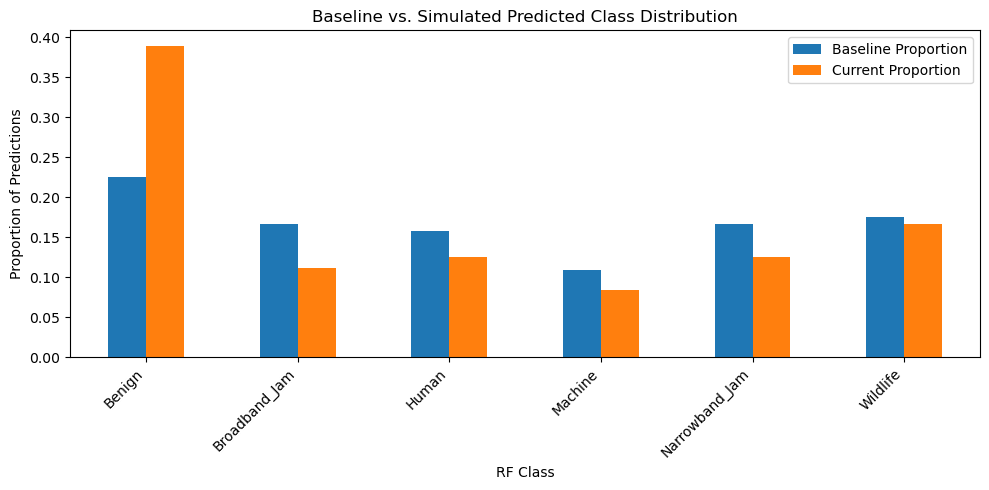

In [14]:
drift_distribution_results[
    ["Baseline Proportion", "Current Proportion"]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Baseline vs. Simulated Predicted Class Distribution")
plt.xlabel("RF Class")
plt.ylabel("Proportion of Predictions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## Model Monitoring Summary

The model monitoring framework establishes baseline expectations for the deployed RF intrusion detection model and provides automated checks for potential performance degradation and changes in prediction behavior.

The monitoring implementation evaluates model accuracy, macro F1-score, mean prediction confidence, low-confidence prediction rate, and predicted class distribution. Threshold-based monitoring successfully returned a PASS status when evaluated against the established model baseline and generated ALERT statuses when intentionally degraded model metrics were introduced.

Class-distribution monitoring was also implemented using normalized prediction proportions to account for differences in batch size. The baseline distribution returned a PASS status, while a simulated shifted distribution successfully triggered an ALERT. Together, these tests demonstrate that the monitoring framework can identify both model-performance degradation and changes in prediction behavior.

The degraded performance and distribution-shift examples used in this notebook are simulated validation scenarios and do not represent observed production failures. Future batch inference results can be passed through the same monitoring functions to evaluate actual deployed model behavior.

# Part 2: Data Monitoring

Data monitoring evaluates whether incoming RF data remains consistent with the reference data used to develop and evaluate the intrusion detection model. Changes in the statistical characteristics, class composition, schema, or quality of incoming data may indicate data drift or pipeline problems that could negatively affect model performance.

The data monitoring framework evaluates reference and current batch data using data-quality and distribution checks. Monitoring focuses on missing values, schema consistency, dataset structure, class composition, and measurable class-distribution drift.

## Identify Reference and Production Data

Data monitoring requires a reference dataset representing expected model input characteristics and a current dataset representing production inputs. The deployed CNN v2 model performs batch inference on the curated production holdout spectrograms. The corresponding training split will be used as the reference distribution for data-quality and drift comparisons.

In [16]:
# S3 configuration used by the deployed CNN v2 workflow

region = "us-east-1"
bucket = "sagemaker-us-east-1-738929456112"

assignment_split_prefix = (
    "rf-intrusion-datalake/curated/assignment_split/"
)

production_prefix = (
    "rf-intrusion-datalake/curated/assignment_split/production/"
)

s3 = boto3.client("s3", region_name=region)

print("Data Monitoring Configuration")
print("=" * 60)
print("S3 Bucket:")
print(bucket)

print("\nAssignment Split:")
print(f"s3://{bucket}/{assignment_split_prefix}")

print("\nProduction Dataset:")
print(f"s3://{bucket}/{production_prefix}")

Data Monitoring Configuration
S3 Bucket:
sagemaker-us-east-1-738929456112

Assignment Split:
s3://sagemaker-us-east-1-738929456112/rf-intrusion-datalake/curated/assignment_split/

Production Dataset:
s3://sagemaker-us-east-1-738929456112/rf-intrusion-datalake/curated/assignment_split/production/


## Load Data Monitoring Metadata

The assignment split metadata is used to establish the reference and production datasets for monitoring. The `assignment_split` field identifies the dataset partition used by the MLOps workflow, while `class_label` identifies the six RF activity classes.

The training partition serves as the reference distribution representing expected data characteristics. Production observations are evaluated against this reference to identify potential changes in data composition.

In [17]:
import subprocess
import io
import pandas as pd

# Read Jacob's assignment-split metadata directly from his Git branch
result = subprocess.run(
    [
        "git",
        "show",
        "origin/jacob/sagemaker-batch-deployment:rf_intrusion_assignment_split_metadata.csv"
    ],
    capture_output=True,
    text=True,
    check=True
)

# Load the Git output directly into pandas
metadata = pd.read_csv(io.StringIO(result.stdout))

print("Metadata Shape:", metadata.shape)

print("\nColumns:")
print(metadata.columns.tolist())

print("\nAssignment Split Counts:")
print(metadata["assignment_split"].value_counts())

print("\nClass Counts:")
print(metadata["class_label"].value_counts())

print("\nFirst 5 Records:")
display(metadata.head())

Metadata Shape: (24000, 5)

Columns:
['image_path', 'filename', 'class_label', 'original_split', 'assignment_split']

Assignment Split Counts:
assignment_split
train         9600
production    9600
validation    2400
test          2400
Name: count, dtype: int64

Class Counts:
class_label
Human             4000
Benign            4000
Narrowband_Jam    4000
Broadband_Jam     4000
Machine           4000
Wildlife          4000
Name: count, dtype: int64

First 5 Records:


,image_path,filename,class_label,original_split,assignment_split
0,/home/sagemaker-user/.cache/kagglehub/datasets...,radar_003904.png,Human,train,train
1,/home/sagemaker-user/.cache/kagglehub/datasets...,dronerf_066126.png,Benign,train,train
2,/home/sagemaker-user/.cache/kagglehub/datasets...,jam_Benign_005449.png,Benign,train,train
3,/home/sagemaker-user/.cache/kagglehub/datasets...,aug_Narrowband_Jam_000695.png,Narrowband_Jam,train,train
4,/home/sagemaker-user/.cache/kagglehub/datasets...,aug_Narrowband_Jam_000377.png,Narrowband_Jam,train,train


### Data Quality Checks

Basic data-quality checks are performed before distribution monitoring. These checks evaluate schema completeness, missing values, duplicate records, expected RF classes, and expected assignment splits. Detecting these issues provides an early indication of potential upstream data-pipeline problems before they affect model performance.

In [18]:
required_columns = [
    "image_path",
    "filename",
    "class_label",
    "original_split",
    "assignment_split"
]

expected_classes = {
    "Benign",
    "Broadband_Jam",
    "Human",
    "Machine",
    "Narrowband_Jam",
    "Wildlife"
}

expected_splits = {
    "train",
    "validation",
    "test",
    "production"
}

quality_results = {
    "Required Columns Present":
        all(col in metadata.columns for col in required_columns),

    "Missing Filenames":
        metadata["filename"].isna().sum(),

    "Missing Class Labels":
        metadata["class_label"].isna().sum(),

    "Missing Assignment Splits":
        metadata["assignment_split"].isna().sum(),

    "Duplicate Filenames":
        metadata["filename"].duplicated().sum(),

    "All Expected Classes Present":
        expected_classes.issubset(
            set(metadata["class_label"].dropna())
        ),

    "All Expected Splits Present":
        expected_splits.issubset(
            set(metadata["assignment_split"].dropna())
        )
}

quality_df = pd.DataFrame(
    quality_results.items(),
    columns=["Data Quality Check", "Result"]
)

quality_df

,Data Quality Check,Result
0,Required Columns Present,True
1,Missing Filenames,0
2,Missing Class Labels,0
3,Missing Assignment Splits,0
4,Duplicate Filenames,0
5,All Expected Classes Present,True
6,All Expected Splits Present,True


## Reference and Production Datasets

The training partition is used as the reference dataset because it represents the data distribution used to develop the deployed model. The production partition represents the current batch data being monitored.

Comparing these partitions allows the monitoring workflow to identify changes in RF class composition between the expected training distribution and production data.

In [19]:
reference_data = metadata[
    metadata["assignment_split"] == "train"
].copy()

production_data = metadata[
    metadata["assignment_split"] == "production"
].copy()

print("Reference Dataset (Train):", len(reference_data))
print("Production Dataset:", len(production_data))

print("\nReference Classes:")
print(reference_data["class_label"].value_counts())

print("\nProduction Classes:")
print(production_data["class_label"].value_counts())

Reference Dataset (Train): 9600
Production Dataset: 9600

Reference Classes:
class_label
Human             1600
Benign            1600
Narrowband_Jam    1600
Broadband_Jam     1600
Machine           1600
Wildlife          1600
Name: count, dtype: int64

Production Classes:
class_label
Benign            1600
Wildlife          1600
Narrowband_Jam    1600
Machine           1600
Human             1600
Broadband_Jam     1600
Name: count, dtype: int64


### Reference vs. Production Class Distribution

Class proportions are calculated independently for the reference and production datasets. Normalized proportions are used instead of raw counts so that the monitoring approach remains valid when future production batch sizes differ.

In [20]:
reference_distribution = (
    reference_data["class_label"]
    .value_counts(normalize=True)
    .sort_index()
)

production_distribution = (
    production_data["class_label"]
    .value_counts(normalize=True)
    .sort_index()
)

data_distribution_comparison = pd.DataFrame({
    "Reference Proportion": reference_distribution,
    "Production Proportion": production_distribution
}).fillna(0)

data_distribution_comparison["Absolute Change"] = (
    data_distribution_comparison["Production Proportion"]
    - data_distribution_comparison["Reference Proportion"]
).abs()

data_distribution_comparison

,Reference Proportion,Production Proportion,Absolute Change
class_label,,,
Benign,0.166667,0.166667,0.0
Broadband_Jam,0.166667,0.166667,0.0
Human,0.166667,0.166667,0.0
Machine,0.166667,0.166667,0.0
Narrowband_Jam,0.166667,0.166667,0.0
Wildlife,0.166667,0.166667,0.0


### Data Distribution Drift Detection

A class-distribution change greater than 5 percentage points relative to the training reference is treated as a potential data-drift alert. This threshold provides an interpretable initial criterion for identifying meaningful changes in production RF activity composition.

In [21]:
DATA_DRIFT_THRESHOLD = 0.05

data_distribution_comparison["Status"] = np.where(
    data_distribution_comparison["Absolute Change"]
    > DATA_DRIFT_THRESHOLD,
    "ALERT",
    "PASS"
)

data_distribution_comparison

,Reference Proportion,Production Proportion,Absolute Change,Status
class_label,,,,
Benign,0.166667,0.166667,0.0,PASS
Broadband_Jam,0.166667,0.166667,0.0,PASS
Human,0.166667,0.166667,0.0,PASS
Machine,0.166667,0.166667,0.0,PASS
Narrowband_Jam,0.166667,0.166667,0.0,PASS
Wildlife,0.166667,0.166667,0.0,PASS


In [22]:
overall_data_status = (
    "ALERT"
    if (data_distribution_comparison["Status"] == "ALERT").any()
    else "PASS"
)

print("Overall Data Distribution Status:", overall_data_status)

Overall Data Distribution Status: PASS


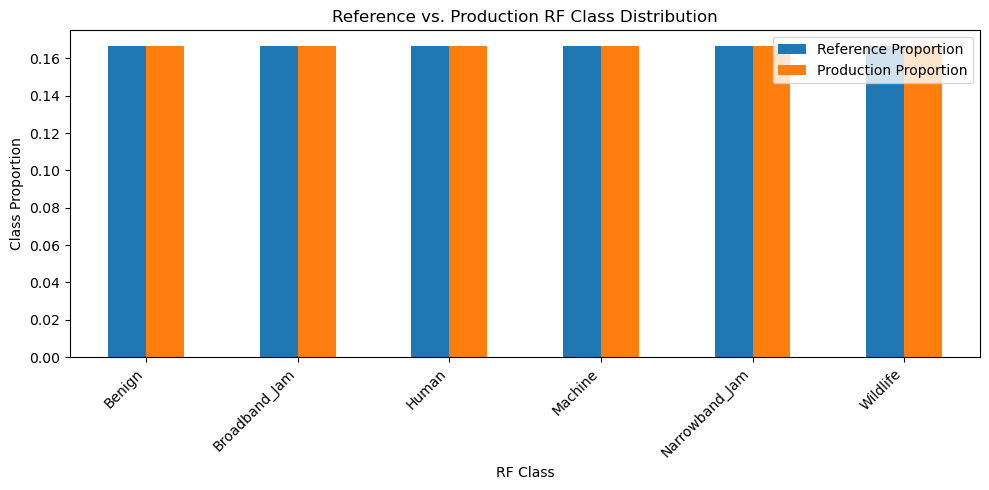

In [23]:
data_distribution_comparison[
    ["Reference Proportion", "Production Proportion"]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Reference vs. Production RF Class Distribution")
plt.xlabel("RF Class")
plt.ylabel("Class Proportion")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## Dataset Structure Monitoring

In addition to class-distribution monitoring, the production dataset is evaluated for structural consistency with the reference dataset. Structural monitoring verifies that expected RF classes are represented, filenames are valid, records are unique, and the production partition contains the expected metadata fields.

These checks complement distribution monitoring by detecting upstream data-pipeline problems that may not appear as changes in class proportions.

In [25]:
def evaluate_split_quality(data, split_name):
    return {
        "Split": split_name,
        "Records": len(data),
        "Missing Filenames": data["filename"].isna().sum(),
        "Missing Labels": data["class_label"].isna().sum(),
        "Duplicate Filenames": data["filename"].duplicated().sum(),
        "Unique Classes": data["class_label"].nunique(),
        "Expected Classes Present": expected_classes.issubset(
            set(data["class_label"].dropna())
        )
    }


reference_quality = evaluate_split_quality(
    reference_data,
    "Reference (Train)"
)

production_quality = evaluate_split_quality(
    production_data,
    "Production"
)

split_quality_df = pd.DataFrame([
    reference_quality,
    production_quality
])

split_quality_df

,Split,Records,Missing Filenames,Missing Labels,Duplicate Filenames,Unique Classes,Expected Classes Present
0,Reference (Train),9600,0,0,0,6,True
1,Production,9600,0,0,0,6,True


## Image-Level Input Drift Monitoring

Because the deployed CNN operates directly on RF spectrogram images, class-distribution monitoring alone cannot detect all forms of input drift. Production images may maintain the same class composition while their underlying visual characteristics change.

To extend data monitoring to the model-input level, a representative sample of training-reference and production spectrograms is evaluated using image-level statistics. The monitoring process compares image dimensions, mean pixel intensity, and pixel-intensity standard deviation between the two datasets. These measurements provide a lightweight method for detecting changes in the visual characteristics of incoming RF spectrograms.

In [26]:
print("Reference image path examples:")
print(reference_data["image_path"].head(5).tolist())

print("\nProduction image path examples:")
print(production_data["image_path"].head(5).tolist())

Reference image path examples:
['/home/sagemaker-user/.cache/kagglehub/datasets/hector484/unified-multi-class-rf-intrusion-dataset/versions/1/unified_dataset/train/Human/radar_003904.png', '/home/sagemaker-user/.cache/kagglehub/datasets/hector484/unified-multi-class-rf-intrusion-dataset/versions/1/unified_dataset/train/Benign/dronerf_066126.png', '/home/sagemaker-user/.cache/kagglehub/datasets/hector484/unified-multi-class-rf-intrusion-dataset/versions/1/unified_dataset/train/Benign/jam_Benign_005449.png', '/home/sagemaker-user/.cache/kagglehub/datasets/hector484/unified-multi-class-rf-intrusion-dataset/versions/1/unified_dataset/train/Narrowband_Jam/aug_Narrowband_Jam_000695.png', '/home/sagemaker-user/.cache/kagglehub/datasets/hector484/unified-multi-class-rf-intrusion-dataset/versions/1/unified_dataset/train/Narrowband_Jam/aug_Narrowband_Jam_000377.png']

Production image path examples:
['/home/sagemaker-user/.cache/kagglehub/datasets/hector484/unified-multi-class-rf-intrusion-datas

In [27]:
from pathlib import Path

reference_example = Path(
    reference_data["image_path"].iloc[0]
)

production_example = Path(
    production_data["image_path"].iloc[0]
)

print("Reference image exists:", reference_example.exists())
print("Reference path:", reference_example)

print("\nProduction image exists:", production_example.exists())
print("Production path:", production_example)

Reference image exists: True
Reference path: /home/sagemaker-user/.cache/kagglehub/datasets/hector484/unified-multi-class-rf-intrusion-dataset/versions/1/unified_dataset/train/Human/radar_003904.png

Production image exists: True
Production path: /home/sagemaker-user/.cache/kagglehub/datasets/hector484/unified-multi-class-rf-intrusion-dataset/versions/1/unified_dataset/train/Benign/dronerf_071065.png


### Spectrogram Image Statistics

A representative sample of reference and production spectrograms is analyzed to characterize the actual inputs consumed by the CNN. For each image, the monitoring process measures image dimensions, mean pixel intensity, and pixel-intensity standard deviation.

The same sampling procedure is applied to both datasets to provide a consistent comparison while avoiding the computational cost of processing all 19,200 reference and production images.

In [28]:
from PIL import Image

IMAGE_SAMPLE_SIZE = 500
RANDOM_STATE = 42

reference_sample = reference_data.sample(
    n=min(IMAGE_SAMPLE_SIZE, len(reference_data)),
    random_state=RANDOM_STATE
)

production_sample = production_data.sample(
    n=min(IMAGE_SAMPLE_SIZE, len(production_data)),
    random_state=RANDOM_STATE
)

print("Reference sample size:", len(reference_sample))
print("Production sample size:", len(production_sample))

Reference sample size: 500
Production sample size: 500


In [29]:
def extract_image_statistics(data):
    records = []

    for image_path in data["image_path"]:
        path = Path(image_path)

        if not path.exists():
            continue

        with Image.open(path) as img:
            img_array = np.asarray(
                img.convert("RGB"),
                dtype=np.float32
            )

            records.append({
                "width": img.width,
                "height": img.height,
                "mean_intensity": img_array.mean(),
                "std_intensity": img_array.std()
            })

    return pd.DataFrame(records)


reference_image_stats = extract_image_statistics(
    reference_sample
)

production_image_stats = extract_image_statistics(
    production_sample
)

print(
    "Reference images successfully analyzed:",
    len(reference_image_stats)
)

print(
    "Production images successfully analyzed:",
    len(production_image_stats)
)

Reference images successfully analyzed: 500
Production images successfully analyzed: 500


In [30]:
image_stats_comparison = pd.DataFrame({
    "Reference": [
        reference_image_stats["mean_intensity"].mean(),
        reference_image_stats["std_intensity"].mean(),
        reference_image_stats["width"].mean(),
        reference_image_stats["height"].mean()
    ],
    "Production": [
        production_image_stats["mean_intensity"].mean(),
        production_image_stats["std_intensity"].mean(),
        production_image_stats["width"].mean(),
        production_image_stats["height"].mean()
    ]
}, index=[
    "Mean Pixel Intensity",
    "Mean Pixel Std Dev",
    "Mean Width",
    "Mean Height"
])

image_stats_comparison["Absolute Change"] = (
    image_stats_comparison["Production"]
    - image_stats_comparison["Reference"]
).abs()

image_stats_comparison["Percent Change"] = (
    image_stats_comparison["Absolute Change"]
    / image_stats_comparison["Reference"]
) * 100

image_stats_comparison

,Reference,Production,Absolute Change,Percent Change
Mean Pixel Intensity,120.009201,116.111801,3.897400,3.247584
Mean Pixel Std Dev,29.114061,28.596714,0.517347,1.776967
Mean Width,224.000000,224.000000,0.000000,0.000000
Mean Height,224.000000,224.000000,0.000000,0.000000


### Image Dimension Consistency

Image dimensions are checked separately because unexpected changes in input shape may indicate preprocessing or upstream pipeline problems and can prevent the deployed CNN from processing incoming data correctly.

In [31]:
reference_dimensions = (
    reference_image_stats[["width", "height"]]
    .value_counts()
    .reset_index(name="count")
)

production_dimensions = (
    production_image_stats[["width", "height"]]
    .value_counts()
    .reset_index(name="count")
)

print("Reference Image Dimensions")
display(reference_dimensions)

print("\nProduction Image Dimensions")
display(production_dimensions)

Reference Image Dimensions


,width,height,count
0,224,224,500



Production Image Dimensions


,width,height,count
0,224,224,500


### Pixel-Intensity Distribution Comparison

The distributions of mean pixel intensity are compared between the training-reference and production samples. Similar distributions indicate that the overall visual intensity characteristics of incoming spectrograms remain consistent with the reference data, while substantial separation may indicate input drift.

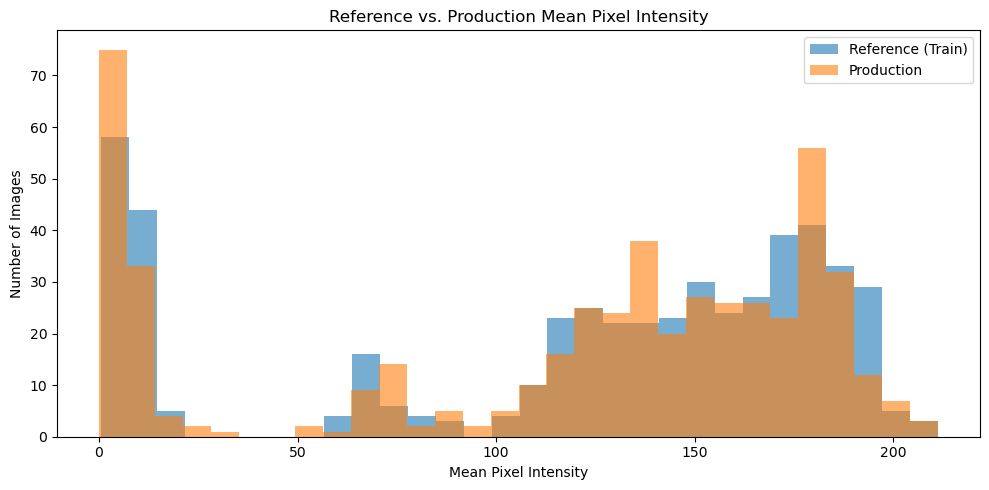

In [32]:
plt.figure(figsize=(10, 5))

plt.hist(
    reference_image_stats["mean_intensity"],
    bins=30,
    alpha=0.6,
    label="Reference (Train)"
)

plt.hist(
    production_image_stats["mean_intensity"],
    bins=30,
    alpha=0.6,
    label="Production"
)

plt.title("Reference vs. Production Mean Pixel Intensity")
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Number of Images")
plt.legend()
plt.tight_layout()

plt.show()

### Image-Level Drift Detection

Image-level monitoring compares aggregate visual characteristics of the production spectrograms with the training reference sample. An initial relative-change threshold of 10% is used for mean pixel intensity and pixel-intensity standard deviation.

Image dimensions are monitored separately and must remain consistent with the expected 224 × 224 input dimensions. These thresholds provide an initial operational monitoring criterion and can be refined as additional production batches become available.

In [33]:
IMAGE_DRIFT_THRESHOLD = 10.0
EXPECTED_WIDTH = 224
EXPECTED_HEIGHT = 224

mean_intensity_change = image_stats_comparison.loc[
    "Mean Pixel Intensity", "Percent Change"
]

std_intensity_change = image_stats_comparison.loc[
    "Mean Pixel Std Dev", "Percent Change"
]

dimension_pass = (
    (production_image_stats["width"] == EXPECTED_WIDTH).all()
    and
    (production_image_stats["height"] == EXPECTED_HEIGHT).all()
)

image_drift_results = pd.DataFrame({
    "Metric": [
        "Mean Pixel Intensity",
        "Pixel Intensity Std Dev",
        "Image Dimensions"
    ],
    "Observed Change": [
        f"{mean_intensity_change:.2f}%",
        f"{std_intensity_change:.2f}%",
        "224 x 224"
    ],
    "Threshold": [
        "<= 10%",
        "<= 10%",
        "224 x 224"
    ],
    "Status": [
        "PASS" if mean_intensity_change <= IMAGE_DRIFT_THRESHOLD else "ALERT",
        "PASS" if std_intensity_change <= IMAGE_DRIFT_THRESHOLD else "ALERT",
        "PASS" if dimension_pass else "ALERT"
    ]
})

image_drift_results

,Metric,Observed Change,Threshold,Status
0,Mean Pixel Intensity,3.25%,<= 10%,PASS
1,Pixel Intensity Std Dev,1.78%,<= 10%,PASS
2,Image Dimensions,224 x 224,224 x 224,PASS


In [34]:
overall_image_drift_status = (
    "ALERT"
    if (image_drift_results["Status"] == "ALERT").any()
    else "PASS"
)

print("Overall Image-Level Drift Status:", overall_image_drift_status)

Overall Image-Level Drift Status: PASS


### Final Data Monitoring Status

The final monitoring status combines metadata and structural data-quality checks, class-distribution monitoring, and image-level input drift monitoring. An alert in any of these monitoring components results in an overall data-monitoring alert.

In [35]:
data_quality_pass = (
    production_data["filename"].isna().sum() == 0
    and production_data["class_label"].isna().sum() == 0
    and production_data["filename"].duplicated().sum() == 0
    and expected_classes.issubset(
        set(production_data["class_label"].dropna())
    )
)

distribution_pass = overall_data_status == "PASS"
image_drift_pass = overall_image_drift_status == "PASS"

overall_data_monitor_status = (
    "PASS"
    if data_quality_pass
    and distribution_pass
    and image_drift_pass
    else "ALERT"
)

print(
    "Data Quality Status:",
    "PASS" if data_quality_pass else "ALERT"
)

print(
    "Class Distribution Status:",
    overall_data_status
)

print(
    "Image-Level Drift Status:",
    overall_image_drift_status
)

print(
    "Overall Data Monitor Status:",
    overall_data_monitor_status
)

Data Quality Status: PASS
Class Distribution Status: PASS
Image-Level Drift Status: PASS
Overall Data Monitor Status: PASS


## Data Monitoring Summary

The data monitoring framework evaluates the quality, structure, class composition, and image-level characteristics of production RF data relative to the training reference dataset. The assignment metadata contained 24,000 observations distributed across training, validation, test, and production partitions.

Data-quality checks confirmed that all required metadata fields and expected RF classes were present, with no missing filenames, missing class labels, missing assignment splits, or duplicate filenames. Structural checks also confirmed that the training reference and production partitions each contained 9,600 records representing all six expected RF classes.

Class-distribution monitoring compared normalized class proportions between the training reference and production datasets using a 5-percentage-point drift threshold. Each RF class represented approximately 16.67% of both datasets, resulting in zero observed class-composition change and a PASS status for all six classes.

Image-level monitoring was additionally performed on representative samples of 500 training-reference and 500 production spectrograms. All sampled images maintained the expected 224 × 224 dimensions. Mean pixel intensity changed by approximately 3.25%, while mean pixel-intensity standard deviation changed by approximately 1.78%. Both remained within the initial 10% monitoring threshold, resulting in a PASS for image-level input drift.

Combined with the metadata-quality, structural, class-distribution, and image-level checks, the production dataset received an overall PASS status under the implemented monitoring criteria.

# Monitoring Conclusions

Model and data monitoring were implemented for the SageMaker Batch Transform RF intrusion detection workflow. The model-monitoring framework tracks accuracy, macro F1-score, prediction confidence, low-confidence prediction rate, and predicted class distribution against established baseline behavior. Validation tests demonstrated that the monitoring logic maintains a PASS status under expected conditions and generates ALERT statuses when simulated performance degradation or prediction-distribution shifts exceed the defined thresholds.

The data-monitoring framework evaluates metadata quality, dataset structure, RF class composition, and image-level characteristics between the training reference and production datasets. The current production dataset passed all implemented data-quality, class-distribution, and image-level drift checks.

Together, these monitoring components provide reusable PASS/ALERT outputs that can support subsequent infrastructure monitoring, CloudWatch dashboard development, and model/data reporting activities in the Group 6 MLOps pipeline.

# Part 3: Analyze Model Quality CloudWatch Metrics

This section follows the Amazon SageMaker Model Quality Monitor CloudWatch pattern:

1. Publish / collect model-quality metrics
2. List CloudWatch metrics
3. Create CloudWatch alarms when metrics drift from baseline thresholds
4. Validate alarms in the CloudWatch console
5. Create a CloudWatch monitoring dashboard for the ML job/endpoint

Because this project primarily uses **SageMaker Batch Transform**, metrics are published to a project namespace (`RFIntrusion/MLMonitoring`). If a real-time endpoint + Model Quality Monitor schedule is added later, the same alarm/dashboard pattern works with the `aws/sagemaker/Endpoints/model-metrics` namespace used in the AWS template.


## 3.1 Create CloudWatch Client and Metric Dimensions

Create a CloudWatch client and define the metric namespace/dimensions used for monitoring. This mirrors the template approach of configuring `cw_client`, `namespace`, and `cw_dimensions` before listing metrics or creating alarms.


In [36]:
# ============================================
# Create CloudWatch client (template style)
# ============================================

from datetime import datetime, timezone

cw_client = boto3.Session().client("cloudwatch")
sm_client = boto3.client("sagemaker")
sts_client = boto3.client("sts")

account_id = sts_client.get_caller_identity()["Account"]

# Project custom metrics namespace (Batch Transform / notebook monitors)
namespace = "RFIntrusion/MLMonitoring"

# Optional endpoint + monitoring schedule names if using realtime Model Quality Monitor
ENDPOINT_NAME = os.environ.get("RF_INTRUSION_ENDPOINT_NAME", "")
MONITORING_SCHEDULE_NAME = os.environ.get(
    "RF_INTRUSION_MONITORING_SCHEDULE_NAME",
    "rf-intrusion-model-quality-schedule",
)
BATCH_TRANSFORM_JOB_NAME = os.environ.get("BATCH_TRANSFORM_JOB_NAME", "")

MODEL_VERSION = str(model_baseline.get("model_version", "v1"))

cw_dimensions = [
    {"Name": "ModelVersion", "Value": MODEL_VERSION},
    {"Name": "Project", "Value": "RFIntrusion"},
]

print("CloudWatch namespace:", namespace)
print("Dimensions:", cw_dimensions)
print("Endpoint (optional):", ENDPOINT_NAME or "(not set)")
print("Monitoring schedule (optional):", MONITORING_SCHEDULE_NAME)
print("Batch Transform job (optional):", BATCH_TRANSFORM_JOB_NAME or "(not set)")


CloudWatch namespace: RFIntrusion/MLMonitoring
Dimensions: [{'Name': 'ModelVersion', 'Value': 'v1'}, {'Name': 'Project', 'Value': 'RFIntrusion'}]
Endpoint (optional): (not set)
Monitoring schedule (optional): rf-intrusion-model-quality-schedule
Batch Transform job (optional): (not set)


## 3.2 Publish Current Model Quality Metrics

Publish the latest model-monitoring values so CloudWatch has datapoints to list, alarm on, and chart. In the AWS template these metrics are emitted by a Model Quality Monitor schedule; here we publish equivalent custom metrics from Parts 1–2.


In [37]:
# ============================================
# Publish model-quality metrics to CloudWatch
# ============================================

def put_model_quality_metric(metric_name, value, unit="None"):
    cw_client.put_metric_data(
        Namespace=namespace,
        MetricData=[
            {
                "MetricName": metric_name,
                "Dimensions": cw_dimensions,
                "Value": float(value),
                "Unit": unit,
            }
        ],
    )
    print(f"Published {metric_name}={value}")


def status_to_flag(status):
    return 1.0 if str(status).upper() == "ALERT" else 0.0


# Current snapshot from Part 1 baseline monitor (replace with live batch metrics when available)
current_accuracy = float(model_baseline["test_accuracy"])
current_macro_f1 = float(model_baseline["macro_f1"])
current_mean_confidence = float(model_baseline["mean_prediction_confidence"])
current_low_conf_rate = float(model_baseline["low_confidence_rate"])
current_model_status = get_overall_model_status(baseline_monitor_results)

try:
    current_class_dist_status = get_distribution_status(baseline_distribution_results)
except NameError:
    current_class_dist_status = "PASS"

try:
    current_data_status = overall_data_monitor_status
except NameError:
    current_data_status = "PASS"

put_model_quality_metric("TestAccuracy", current_accuracy)
put_model_quality_metric("MacroF1", current_macro_f1)
put_model_quality_metric("MeanPredictionConfidence", current_mean_confidence)
put_model_quality_metric("LowConfidenceRate", current_low_conf_rate)
put_model_quality_metric("ModelAlert", status_to_flag(current_model_status))
put_model_quality_metric("ClassDistributionAlert", status_to_flag(current_class_dist_status))
put_model_quality_metric("DataMonitorAlert", status_to_flag(current_data_status))

# Align naming with template-style quality score metric used by alarms/dashboard
put_model_quality_metric("f1", current_macro_f1)

print("\nModel quality metrics published.")


Published TestAccuracy=0.8361111283302307
Published MacroF1=0.829
Published MeanPredictionConfidence=0.8241221904754639
Published LowConfidenceRate=0.13666666666666666
Published ModelAlert=0.0
Published ClassDistributionAlert=0.0
Published DataMonitorAlert=0.0
Published f1=0.829

Model quality metrics published.


## 3.3 List the CloudWatch Metrics Generated

List metrics through the pagination interface, following the SageMaker Model Quality Monitor template.


In [38]:
# ============================================
# List CloudWatch metrics (template style)
# ============================================

paginator = cw_client.get_paginator("list_metrics")

print(f"Metrics in namespace '{namespace}' with project dimensions:\n")

found_metrics = []
for response in paginator.paginate(Namespace=namespace, Dimensions=cw_dimensions):
    for metric in response["Metrics"]:
        found_metrics.append(metric["MetricName"])
        print(metric["MetricName"])

if not found_metrics:
    print(
        "No metrics returned yet. CloudWatch list_metrics can lag briefly after put_metric_data. "
        "Re-run this cell in 1-2 minutes if needed."
    )

# Optional: also list endpoint model-monitor metrics if an endpoint schedule exists
endpoint_namespace = "aws/sagemaker/Endpoints/model-metrics"
if ENDPOINT_NAME:
    print(f"\nMetrics in '{endpoint_namespace}' for endpoint '{ENDPOINT_NAME}':\n")
    endpoint_dimensions = [
        {"Name": "Endpoint", "Value": ENDPOINT_NAME},
        {"Name": "MonitoringSchedule", "Value": MONITORING_SCHEDULE_NAME},
    ]
    for response in paginator.paginate(
        Namespace=endpoint_namespace,
        Dimensions=endpoint_dimensions,
    ):
        for metric in response["Metrics"]:
            print(metric["MetricName"])


Metrics in namespace 'RFIntrusion/MLMonitoring' with project dimensions:

MeanPredictionConfidence
DataMonitorAlert
f1
MacroF1
TestAccuracy
LowConfidenceRate
ModelAlert
ClassDistributionAlert


## 3.4 Create CloudWatch Alarms

Based on the CloudWatch metrics, create alarms when a metric does not meet the baseline threshold. This follows the template `put_metric_alarm` pattern (for example, alarming when an F-score drifts below the baseline constraint).


In [39]:
# ============================================
# Create CloudWatch alarms (template style)
# ============================================

def create_model_quality_alarm(
    alarm_name,
    alarm_desc,
    metric_name,
    threshold,
    comparison_operator="LessThanOrEqualToThreshold",
    period=600,
    treat_missing_data="breaching",
):
    cw_client.put_metric_alarm(
        AlarmName=alarm_name,
        AlarmDescription=alarm_desc,
        ActionsEnabled=True,
        MetricName=metric_name,
        Namespace=namespace,
        Statistic="Average",
        Dimensions=cw_dimensions,
        Period=period,
        EvaluationPeriods=1,
        DatapointsToAlarm=1,
        Threshold=float(threshold),
        ComparisonOperator=comparison_operator,
        TreatMissingData=treat_missing_data,
    )
    print(f"Created/updated alarm: {alarm_name}")


# Primary quality alarm (analogous to MODEL_QUALITY_F2_SCORE in the template)
model_quality_f1_drift_threshold = monitoring_thresholds["minimum_macro_f1"]

create_model_quality_alarm(
    alarm_name="RF_INTRUSION_MODEL_QUALITY_F1_SCORE",
    alarm_desc=(
        "Trigger a CloudWatch alarm when the macro F1 score drifts away "
        "from the baseline monitoring threshold"
    ),
    metric_name="f1",
    threshold=model_quality_f1_drift_threshold,
    comparison_operator="LessThanOrEqualToThreshold",
)

# Additional operational alarms aligned to Part 1 thresholds
create_model_quality_alarm(
    alarm_name="RF_INTRUSION_MODEL_QUALITY_ACCURACY",
    alarm_desc="Trigger when test accuracy drifts below the baseline threshold",
    metric_name="TestAccuracy",
    threshold=monitoring_thresholds["minimum_accuracy"],
)

create_model_quality_alarm(
    alarm_name="RF_INTRUSION_MODEL_QUALITY_CONFIDENCE",
    alarm_desc="Trigger when mean prediction confidence drifts below threshold",
    metric_name="MeanPredictionConfidence",
    threshold=monitoring_thresholds["minimum_mean_confidence"],
)

create_model_quality_alarm(
    alarm_name="RF_INTRUSION_MODEL_QUALITY_LOW_CONFIDENCE_RATE",
    alarm_desc="Trigger when low-confidence rate exceeds threshold",
    metric_name="LowConfidenceRate",
    threshold=monitoring_thresholds["maximum_low_confidence_rate"],
    comparison_operator="GreaterThanOrEqualToThreshold",
)

# Alert-flag alarms (1 = ALERT)
for alarm_name, metric_name, desc in [
    (
        "RF_INTRUSION_MODEL_ALERT",
        "ModelAlert",
        "Trigger when model monitor reports ALERT",
    ),
    (
        "RF_INTRUSION_CLASS_DISTRIBUTION_ALERT",
        "ClassDistributionAlert",
        "Trigger when class-distribution monitor reports ALERT",
    ),
    (
        "RF_INTRUSION_DATA_ALERT",
        "DataMonitorAlert",
        "Trigger when data monitor reports ALERT",
    ),
]:
    create_model_quality_alarm(
        alarm_name=alarm_name,
        alarm_desc=desc,
        metric_name=metric_name,
        threshold=1.0,
        comparison_operator="GreaterThanOrEqualToThreshold",
        treat_missing_data="notBreaching",
    )

print("\nCloudWatch alarms created/updated.")


Created/updated alarm: RF_INTRUSION_MODEL_QUALITY_F1_SCORE
Created/updated alarm: RF_INTRUSION_MODEL_QUALITY_ACCURACY
Created/updated alarm: RF_INTRUSION_MODEL_QUALITY_CONFIDENCE
Created/updated alarm: RF_INTRUSION_MODEL_QUALITY_LOW_CONFIDENCE_RATE
Created/updated alarm: RF_INTRUSION_MODEL_ALERT
Created/updated alarm: RF_INTRUSION_CLASS_DISTRIBUTION_ALERT
Created/updated alarm: RF_INTRUSION_DATA_ALERT

CloudWatch alarms created/updated.


## 3.5 Validation

In a few minutes, you should see CloudWatch alarms created. An alarm may first be in an **Insufficient Data** state and then move to **OK** or **ALARM**. Verify this in the CloudWatch console under **Alarms**.


In [41]:
# ============================================
# Validate CloudWatch alarms
# ============================================

alarm_names = [
    "RF_INTRUSION_MODEL_QUALITY_F1_SCORE",
    "RF_INTRUSION_MODEL_QUALITY_ACCURACY",
    "RF_INTRUSION_MODEL_QUALITY_CONFIDENCE",
    "RF_INTRUSION_MODEL_QUALITY_LOW_CONFIDENCE_RATE",
    "RF_INTRUSION_MODEL_ALERT",
    "RF_INTRUSION_CLASS_DISTRIBUTION_ALERT",
    "RF_INTRUSION_DATA_ALERT",
]

alarm_response = cw_client.describe_alarms(AlarmNames=alarm_names)
alarms = alarm_response.get("MetricAlarms", [])

alarm_df = pd.DataFrame(
    [
        {
            "AlarmName": a["AlarmName"],
            "State": a.get("StateValue"),
            "Metric": a.get("MetricName"),
            "Threshold": a.get("Threshold"),
            "Comparison": a.get("ComparisonOperator"),
            "Namespace": a.get("Namespace"),
        }
        for a in alarms
    ]
)

print(f"Alarms found: {len(alarms)}")
display(alarm_df)

print(
    "\nOpen CloudWatch Alarms console and confirm states "
    "(Insufficient Data -> OK/ALARM)."
)


Alarms found: 7


,AlarmName,State,Metric,Threshold,Comparison,Namespace
0,RF_INTRUSION_CLASS_DISTRIBUTION_ALERT,OK,ClassDistributionAlert,1.000000,GreaterThanOrEqualToThreshold,RFIntrusion/MLMonitoring
1,RF_INTRUSION_DATA_ALERT,OK,DataMonitorAlert,1.000000,GreaterThanOrEqualToThreshold,RFIntrusion/MLMonitoring
2,RF_INTRUSION_MODEL_ALERT,OK,ModelAlert,1.000000,GreaterThanOrEqualToThreshold,RFIntrusion/MLMonitoring
3,RF_INTRUSION_MODEL_QUALITY_ACCURACY,OK,TestAccuracy,0.786111,LessThanOrEqualToThreshold,RFIntrusion/MLMonitoring
4,RF_INTRUSION_MODEL_QUALITY_CONFIDENCE,OK,MeanPredictionConfidence,0.750000,LessThanOrEqualToThreshold,RFIntrusion/MLMonitoring
5,RF_INTRUSION_MODEL_QUALITY_F1_SCORE,OK,f1,0.779000,LessThanOrEqualToThreshold,RFIntrusion/MLMonitoring
6,RF_INTRUSION_MODEL_QUALITY_LOW_CONFIDENCE_RATE,OK,LowConfidenceRate,0.200000,GreaterThanOrEqualToThreshold,RFIntrusion/MLMonitoring



Open CloudWatch Alarms console and confirm states (Insufficient Data -> OK/ALARM).


## 3.6 Infrastructure Monitors: CPU, Memory, Job Duration, and Batch Failures

This section adds infrastructure-level CloudWatch monitors for the SageMaker Batch Transform workflow:

1. **Batch job success / failure**
2. **Batch job duration**
3. **CPU utilization** (AWS/SageMaker host metrics when available)
4. **Memory utilization** (AWS/SageMaker host metrics when available)

Set your Batch Transform job name below (from the main notebook Section 15), then run all cells in this section. Afterward, re-run the Part 4 dashboard cell (or the dashboard update cell at the end of this section) so the new metrics appear on `RF-Intrusion-ML-Monitoring`.


In [56]:
# ============================================
# Configure Batch Transform job for infra monitors
# ============================================

from datetime import datetime, timezone, timedelta
from botocore.exceptions import ClientError

# >>> EDIT THIS: paste your latest Batch Transform job name from Section 15 <<<
BATCH_TRANSFORM_JOB_NAME = ""  # e.g. "rf-intrusion-cnn-v2-batch-transform-2026-10-05"

# Optional: auto-pick the most recent Completed/Failed transform job if left blank
sm_client = boto3.client("sagemaker")
cw_client = boto3.client("cloudwatch")
sts_client = boto3.client("sts")

account_id = sts_client.get_caller_identity()["Account"]
region = boto3.Session().region_name or "us-east-1"

infra_namespace = "RFIntrusion/MLMonitoring"
infra_dimensions = [
    {"Name": "ModelVersion", "Value": str(globals().get("MODEL_VERSION", "v2"))},
    {"Name": "Project", "Value": "RFIntrusion"},
]

if not BATCH_TRANSFORM_JOB_NAME:
    jobs = sm_client.list_transform_jobs(SortBy="CreationTime", SortOrder="Descending", MaxResults=10)
    summaries = jobs.get("TransformJobSummaries", [])
    if summaries:
        BATCH_TRANSFORM_JOB_NAME = summaries[0]["TransformJobName"]
        print("Auto-selected latest transform job:", BATCH_TRANSFORM_JOB_NAME)
        print("Status:", summaries[0].get("TransformJobStatus"))
    else:
        print("No Batch Transform jobs found in this account/region.")
        print("Run Section 15 in the main notebook first, then set BATCH_TRANSFORM_JOB_NAME.")
else:
    print("Using configured transform job:", BATCH_TRANSFORM_JOB_NAME)

print("Account:", account_id)
print("Region:", region)
print("Infra metric namespace:", infra_namespace)

No Batch Transform jobs found in this account/region.
Run Section 15 in the main notebook first, then set BATCH_TRANSFORM_JOB_NAME.
Account: 738929456112
Region: us-east-1
Infra metric namespace: RFIntrusion/MLMonitoring


In [55]:
# ============================================
# Discover SageMaker CPU / Memory host metrics
# ============================================

# SageMaker publishes instance metrics under AWS/SageMaker
# (exact Host dimension values appear while/after jobs run).

aws_ns = "AWS/SageMaker"
paginator = cw_client.get_paginator("list_metrics")

cpu_metrics = []
mem_metrics = []

for page in paginator.paginate(Namespace=aws_ns, MetricName="CPUUtilization"):
    cpu_metrics.extend(page.get("Metrics", []))

for page in paginator.paginate(Namespace=aws_ns, MetricName="MemoryUtilization"):
    mem_metrics.extend(page.get("Metrics", []))

print(f"Found CPUUtilization metric streams: {len(cpu_metrics)}")
print(f"Found MemoryUtilization metric streams: {len(mem_metrics)}")

# Show a few for visibility
for label, metrics in [("CPU", cpu_metrics[:5]), ("Memory", mem_metrics[:5])]:
    print(f"\nSample {label} metrics:")
    for m in metrics:
        dims = {d["Name"]: d["Value"] for d in m.get("Dimensions", [])}
        print(" -", dims)

# Keep unique Host values if present
def hosts_from(metrics):
    hosts = []
    for m in metrics:
        for d in m.get("Dimensions", []):
            if d["Name"] == "Host":
                hosts.append(d["Value"])
    return sorted(set(hosts))

cpu_hosts = hosts_from(cpu_metrics)
mem_hosts = hosts_from(mem_metrics)
infra_hosts = sorted(set(cpu_hosts) | set(mem_hosts))

print("\nDiscovered Host dimensions:", infra_hosts if infra_hosts else "(none yet)")
print(
    "If empty, run a Batch Transform/training job first, wait a few minutes, "
    "then re-run this cell."
)


Found CPUUtilization metric streams: 0
Found MemoryUtilization metric streams: 0

Sample CPU metrics:

Sample Memory metrics:

Discovered Host dimensions: (none yet)
If empty, run a Batch Transform/training job first, wait a few minutes, then re-run this cell.


In [58]:
# ============================================
# Create CloudWatch alarms: duration, failure, CPU, memory
# ============================================

# Thresholds (adjust for your lab)
MAX_BATCH_DURATION_SECONDS = 60 * 60   # 1 hour
MAX_CPU_UTILIZATION = 90.0             # percent
MAX_MEMORY_UTILIZATION = 90.0          # percent


def upsert_alarm(alarm_name, namespace, metric_name, dimensions, threshold, comparison, desc, period=300):
    cw_client.put_metric_alarm(
        AlarmName=alarm_name,
        AlarmDescription=desc,
        ActionsEnabled=True,
        MetricName=metric_name,
        Namespace=namespace,
        Statistic="Average",
        Dimensions=dimensions,
        Period=period,
        EvaluationPeriods=1,
        DatapointsToAlarm=1,
        Threshold=float(threshold),
        ComparisonOperator=comparison,
        TreatMissingData="notBreaching",
    )
    print(f"Upserted alarm: {alarm_name}")


# 1) Batch failure alarm (custom metric)
upsert_alarm(
    alarm_name="RF_INTRUSION_BATCH_TRANSFORM_FAILURE",
    namespace=infra_namespace,
    metric_name="BatchTransformFailure",
    dimensions=infra_dimensions,
    threshold=1.0,
    comparison="GreaterThanOrEqualToThreshold",
    desc="RF intrusion Batch Transform job failed or did not complete successfully",
)

# 2) Job duration alarm (custom metric)
upsert_alarm(
    alarm_name="RF_INTRUSION_BATCH_JOB_DURATION_HIGH",
    namespace=infra_namespace,
    metric_name="BatchJobDurationSeconds",
    dimensions=infra_dimensions,
    threshold=MAX_BATCH_DURATION_SECONDS,
    comparison="GreaterThanThreshold",
    desc=f"RF intrusion Batch Transform duration exceeded {MAX_BATCH_DURATION_SECONDS} seconds",
    period=60,
)

# 3) CPU / Memory alarms for discovered hosts (built-in SageMaker metrics)
if not infra_hosts:
    print(
        "\nNo Host dimensions found yet for CPU/Memory. "
        "Custom batch failure/duration alarms were still created."
    )
else:
    for host in infra_hosts[:5]:  # cap to avoid creating too many alarms in lab
        host_dims = [{"Name": "Host", "Value": host}]
        safe_host = host.replace("/", "-").replace(":", "-")[:40]

        upsert_alarm(
            alarm_name=f"RF_INTRUSION_CPU_HIGH_{safe_host}",
            namespace=aws_ns,
            metric_name="CPUUtilization",
            dimensions=host_dims,
            threshold=MAX_CPU_UTILIZATION,
            comparison="GreaterThanThreshold",
            desc=f"SageMaker host CPUUtilization > {MAX_CPU_UTILIZATION}% ({host})",
        )

        upsert_alarm(
            alarm_name=f"RF_INTRUSION_MEMORY_HIGH_{safe_host}",
            namespace=aws_ns,
            metric_name="MemoryUtilization",
            dimensions=host_dims,
            threshold=MAX_MEMORY_UTILIZATION,
            comparison="GreaterThanThreshold",
            desc=f"SageMaker host MemoryUtilization > {MAX_MEMORY_UTILIZATION}% ({host})",
        )

print("\nInfrastructure alarms configured.")


Upserted alarm: RF_INTRUSION_BATCH_TRANSFORM_FAILURE
Upserted alarm: RF_INTRUSION_BATCH_JOB_DURATION_HIGH

No Host dimensions found yet for CPU/Memory. Custom batch failure/duration alarms were still created.

Infrastructure alarms configured.


In [60]:
# ============================================
# Validate infrastructure alarms
# ============================================

infra_alarm_names = [
    "RF_INTRUSION_BATCH_TRANSFORM_FAILURE",
    "RF_INTRUSION_BATCH_JOB_DURATION_HIGH",
]

# Include any CPU/Memory alarms just created
existing = cw_client.describe_alarms(AlarmNamePrefix="RF_INTRUSION_")
for a in existing.get("MetricAlarms", []):
    name = a["AlarmName"]
    if "CPU_HIGH" in name or "MEMORY_HIGH" in name or name in infra_alarm_names:
        if name not in infra_alarm_names:
            infra_alarm_names.append(name)

resp = cw_client.describe_alarms(AlarmNames=infra_alarm_names)
alarms = resp.get("MetricAlarms", [])

infra_alarm_df = pd.DataFrame(
    [
        {
            "AlarmName": a["AlarmName"],
            "State": a.get("StateValue"),
            "Metric": a.get("MetricName"),
            "Namespace": a.get("Namespace"),
            "Threshold": a.get("Threshold"),
        }
        for a in alarms
    ]
)

print(f"Infrastructure alarms found: {len(infra_alarm_df)}")
display(infra_alarm_df)

print("\nOpen CloudWatch → Alarms and filter: RF_INTRUSION_")


Infrastructure alarms found: 2


,AlarmName,State,Metric,Namespace,Threshold
0,RF_INTRUSION_BATCH_JOB_DURATION_HIGH,OK,BatchJobDurationSeconds,RFIntrusion/MLMonitoring,3600.0
1,RF_INTRUSION_BATCH_TRANSFORM_FAILURE,OK,BatchTransformFailure,RFIntrusion/MLMonitoring,1.0



Open CloudWatch → Alarms and filter: RF_INTRUSION_


In [63]:
# ============================================
# Update CloudWatch dashboard with infra widgets
# ============================================

DASHBOARD_NAME = globals().get("DASHBOARD_NAME", "RF-Intrusion-ML-Monitoring")
MODEL_VERSION = str(globals().get("MODEL_VERSION", "v2"))
namespace = globals().get("namespace", infra_namespace)

dim_list = ["ModelVersion", MODEL_VERSION, "Project", "RFIntrusion"]

widgets = [
    {
        "type": "metric",
        "x": 0,
        "y": 0,
        "width": 12,
        "height": 6,
        "properties": {
            "title": "Model Quality (Accuracy / F1 / Confidence)",
            "region": region,
            "view": "timeSeries",
            "period": 300,
            "stat": "Average",
            "metrics": [
                [namespace, "TestAccuracy", *dim_list],
                [namespace, "f1", *dim_list],
                [namespace, "MeanPredictionConfidence", *dim_list],
            ],
        },
    },
    {
        "type": "metric",
        "x": 12,
        "y": 0,
        "width": 12,
        "height": 6,
        "properties": {
            "title": "Batch Job Duration (Seconds)",
            "region": region,
            "view": "timeSeries",
            "period": 60,
            "stat": "Average",
            "metrics": [[infra_namespace, "BatchJobDurationSeconds", *dim_list]],
        },
    },
    {
        "type": "metric",
        "x": 0,
        "y": 6,
        "width": 12,
        "height": 6,
        "properties": {
            "title": "Batch Success / Failure Flags",
            "region": region,
            "view": "timeSeries",
            "period": 60,
            "stat": "Average",
            "metrics": [
                [infra_namespace, "BatchTransformSuccess", *dim_list],
                [infra_namespace, "BatchTransformFailure", *dim_list],
            ],
        },
    },
    {
        "type": "metric",
        "x": 12,
        "y": 6,
        "width": 12,
        "height": 6,
        "properties": {
            "title": "Monitor Alert Flags",
            "region": region,
            "view": "timeSeries",
            "period": 300,
            "stat": "Average",
            "metrics": [
                [namespace, "ModelAlert", *dim_list],
                [namespace, "ClassDistributionAlert", *dim_list],
                [namespace, "DataMonitorAlert", *dim_list],
            ],
        },
    },
]

# CPU / Memory widgets if hosts were discovered
y_next = 12
if infra_hosts:
    cpu_metric_list = [["AWS/SageMaker", "CPUUtilization", "Host", h] for h in infra_hosts[:3]]
    mem_metric_list = [["AWS/SageMaker", "MemoryUtilization", "Host", h] for h in infra_hosts[:3]]
    widgets.append(
        {
            "type": "metric",
            "x": 0,
            "y": y_next,
            "width": 12,
            "height": 6,
            "properties": {
                "title": "SageMaker Host CPU Utilization (%)",
                "region": region,
                "view": "timeSeries",
                "period": 300,
                "stat": "Average",
                "metrics": cpu_metric_list,
            },
        }
    )
    widgets.append(
        {
            "type": "metric",
            "x": 12,
            "y": y_next,
            "width": 12,
            "height": 6,
            "properties": {
                "title": "SageMaker Host Memory Utilization (%)",
                "region": region,
                "view": "timeSeries",
                "period": 300,
                "stat": "Average",
                "metrics": mem_metric_list,
            },
        }
    )
    y_next += 6

# Alarm strip
alarm_names_for_dash = [
    "RF_INTRUSION_MODEL_QUALITY_F1_SCORE",
    "RF_INTRUSION_BATCH_TRANSFORM_FAILURE",
    "RF_INTRUSION_BATCH_JOB_DURATION_HIGH",
] + [a for a in infra_alarm_names if "CPU_HIGH" in a or "MEMORY_HIGH" in a]

widgets.append(
    {
        "type": "alarm",
        "x": 0,
        "y": y_next,
        "width": 24,
        "height": 3,
        "properties": {
            "title": "RF Intrusion Alarms (Model + Infrastructure)",
            "alarms": [
                f"arn:aws:cloudwatch:{region}:{account_id}:alarm:{name}"
                for name in alarm_names_for_dash
            ],
        },
    }
)

cw_client.put_dashboard(
    DashboardName=DASHBOARD_NAME,
    DashboardBody=json.dumps({"widgets": widgets}),
)

dashboard_url = (
    f"https://{region}.console.aws.amazon.com/cloudwatch/home"
    f"?region={region}#dashboards/dashboard/{DASHBOARD_NAME}"
)

print("Dashboard updated:", DASHBOARD_NAME)
print("Widgets:", len(widgets))
print(dashboard_url)


Dashboard updated: RF-Intrusion-ML-Monitoring
Widgets: 5
https://us-east-1.console.aws.amazon.com/cloudwatch/home?region=us-east-1#dashboards/dashboard/RF-Intrusion-ML-Monitoring


# Part 4: Create a CloudWatch Monitoring Dashboard

Create a CloudWatch dashboard for the ML endpoint/job so model-quality metrics and alarms are visible in one operations view. This extends the template alarm workflow with a dashboard for assignment evidence and ongoing monitoring.


In [64]:
# ============================================
# Verify dashboard exists
# ============================================

names = [
    d["DashboardName"]
    for d in cw_client.list_dashboards().get("DashboardEntries", [])
]

print("Dashboards:")
for name in names:
    marker = " <--" if name == DASHBOARD_NAME else ""
    print(f" - {name}{marker}")

assert DASHBOARD_NAME in names, f"{DASHBOARD_NAME} not found"

detail = cw_client.get_dashboard(DashboardName=DASHBOARD_NAME)
body = json.loads(detail["DashboardBody"])
print("\nVerified widget count:", len(body.get("widgets", [])))
print(dashboard_url)


Dashboards:
 - RF-Intrusion-ML-Monitoring <--

Verified widget count: 5
https://us-east-1.console.aws.amazon.com/cloudwatch/home?region=us-east-1#dashboards/dashboard/RF-Intrusion-ML-Monitoring


## CloudWatch Monitoring Summary

Following the SageMaker Model Quality Monitor CloudWatch template, this notebook now:

1. Publishes model-quality metrics to CloudWatch
2. Lists metrics with the CloudWatch paginator
3. Creates threshold alarms (including an F1 quality alarm analogous to the template F2 alarm)
4. Validates alarm creation/state
5. Creates the **`RF-Intrusion-ML-Monitoring`** dashboard for the ML job/endpoint

**Evidence for the assignment:** screenshot CloudWatch Alarms and the dashboard URL printed above.


# Part 5: Generate Model and Data Reports on SageMaker

This section generates SageMaker-style monitoring reports for model quality and data quality, then uploads them to Amazon S3. The report layout follows the Model Quality Monitor pattern used in AWS examples:

- `statistics.json` — observed metrics
- `constraints.json` — monitoring thresholds / expected constraints
- `constraint_violations.json` — failed checks (ALERT items)
- CSV/JSON summary reports for assignment evidence

Reports are stored under:

`s3://<bucket>/rf-intrusion-datalake/monitoring/reports/<timestamp>/`


## 5.1 Configure Report Output Locations

Define local and S3 report prefixes. Prefer the project bucket discovered earlier in the notebook; fall back to the SageMaker default-style bucket for this account/region.


In [45]:
# ============================================
# Configure SageMaker monitoring report paths
# ============================================

from datetime import datetime, timezone
import json
from pathlib import Path
from botocore.exceptions import ClientError

report_timestamp = datetime.now(timezone.utc).strftime("%Y-%m-%d-%H-%M-%S")

_session = boto3.Session()
report_region = _session.region_name or "us-east-1"
_account = boto3.client("sts").get_caller_identity()["Account"]
report_bucket = f"sagemaker-{report_region}-{_account}"

reports_prefix = f"rf-intrusion-datalake/monitoring/reports/{report_timestamp}"
s3_report_path = f"s3://{report_bucket}/{reports_prefix}"

local_report_dir = Path("monitoring_reports") / report_timestamp
local_report_dir.mkdir(parents=True, exist_ok=True)

model_report_dir = local_report_dir / "model_quality"
data_report_dir = local_report_dir / "data_quality"
model_report_dir.mkdir(parents=True, exist_ok=True)
data_report_dir.mkdir(parents=True, exist_ok=True)

s3_client = boto3.client("s3", region_name=report_region)

try:
    s3_client.head_bucket(Bucket=report_bucket)
    print("Using existing bucket:", report_bucket)
except ClientError:
    print("Creating bucket:", report_bucket)
    if report_region == "us-east-1":
        s3_client.create_bucket(Bucket=report_bucket)
    else:
        s3_client.create_bucket(
            Bucket=report_bucket,
            CreateBucketConfiguration={"LocationConstraint": report_region},
        )

print("AWS account:", _account)
print("Report timestamp:", report_timestamp)
print("Local report dir:", local_report_dir.resolve())
print("S3 report path:", s3_report_path)

Using existing bucket: sagemaker-us-east-1-738929456112
AWS account: 738929456112
Report timestamp: 2026-10-05-23-13-57
Local report dir: /home/sagemaker-user/aai-540-final-project-group6/monitoring_reports/2026-10-05-23-13-57
S3 report path: s3://sagemaker-us-east-1-738929456112/rf-intrusion-datalake/monitoring/reports/2026-10-05-23-13-57


## 5.2 Build Model Quality Report

Create model-quality statistics, constraints, and constraint violations from Part 1 monitoring outputs (baseline metrics, thresholds, and PASS/ALERT statuses).


In [46]:
# ============================================
# Generate model quality monitoring reports
# ============================================

# Gather latest model monitor table if available
try:
    _model_results_df = baseline_monitor_results.copy()
except NameError:
    _model_results_df = monitor_model_performance(
        accuracy=model_baseline["test_accuracy"],
        macro_f1=model_baseline["macro_f1"],
        mean_confidence=model_baseline["mean_prediction_confidence"],
        low_confidence_rate=model_baseline["low_confidence_rate"],
    )

model_statistics = {
    "version": "1.0",
    "dataset_type": "model_quality",
    "problem_type": "MulticlassClassification",
    "model_version": str(model_baseline.get("model_version", "v1")),
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "multiclass_classification_metrics": {
        "accuracy": {
            "value": float(model_baseline["test_accuracy"]),
            "standard_deviation": None,
        },
        "macro_f1": {
            "value": float(model_baseline["macro_f1"]),
            "standard_deviation": None,
        },
        "mean_prediction_confidence": {
            "value": float(model_baseline["mean_prediction_confidence"]),
            "standard_deviation": None,
        },
        "low_confidence_rate": {
            "value": float(model_baseline["low_confidence_rate"]),
            "standard_deviation": None,
        },
    },
    "predicted_class_distribution": model_baseline.get(
        "predicted_class_distribution", {}
    ),
}

model_constraints = {
    "version": "1.0",
    "dataset_type": "model_quality",
    "problem_type": "MulticlassClassification",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "multiclass_classification_constraints": {
        "accuracy": {
            "threshold": float(monitoring_thresholds["minimum_accuracy"]),
            "comparison_operator": "GreaterThanOrEqualToThreshold",
        },
        "macro_f1": {
            "threshold": float(monitoring_thresholds["minimum_macro_f1"]),
            "comparison_operator": "GreaterThanOrEqualToThreshold",
        },
        "mean_prediction_confidence": {
            "threshold": float(monitoring_thresholds["minimum_mean_confidence"]),
            "comparison_operator": "GreaterThanOrEqualToThreshold",
        },
        "low_confidence_rate": {
            "threshold": float(monitoring_thresholds["maximum_low_confidence_rate"]),
            "comparison_operator": "LessThanOrEqualToThreshold",
        },
    },
}

model_violations = []
for metric_name, row in _model_results_df.iterrows():
    if str(row["status"]).upper() == "ALERT":
        model_violations.append(
            {
                "feature_name": metric_name,
                "constraint_check_type": "model_quality_threshold",
                "description": (
                    f"{metric_name} value {row['value']} failed threshold "
                    f"{row['threshold']} (status={row['status']})"
                ),
            }
        )

model_constraint_violations = {
    "version": "1.0",
    "violations": model_violations,
}

# Save Model Monitor-style JSON reports
model_stats_path = model_report_dir / "statistics.json"
model_constraints_path = model_report_dir / "constraints.json"
model_violations_path = model_report_dir / "constraint_violations.json"
model_summary_csv = model_report_dir / "model_quality_summary.csv"

with open(model_stats_path, "w") as f:
    json.dump(model_statistics, f, indent=2)
with open(model_constraints_path, "w") as f:
    json.dump(model_constraints, f, indent=2)
with open(model_violations_path, "w") as f:
    json.dump(model_constraint_violations, f, indent=2)

_model_results_df.to_csv(model_summary_csv)

print("Model quality reports written:")
print(" -", model_stats_path)
print(" -", model_constraints_path)
print(" -", model_violations_path)
print(" -", model_summary_csv)
print("Violations:", len(model_violations))
display(_model_results_df)


Model quality reports written:
 - monitoring_reports/2026-10-05-23-13-57/model_quality/statistics.json
 - monitoring_reports/2026-10-05-23-13-57/model_quality/constraints.json
 - monitoring_reports/2026-10-05-23-13-57/model_quality/constraint_violations.json
 - monitoring_reports/2026-10-05-23-13-57/model_quality/model_quality_summary.csv
Violations: 0


,value,threshold,status
Accuracy,0.836111,0.786111,PASS
Macro F1,0.829,0.779,PASS
Mean Confidence,0.824122,0.75,PASS
Low Confidence Rate,0.136667,0.2,PASS


## 5.3 Build Data Quality Report

Create data-quality statistics, constraints, and violations from Part 2 monitoring outputs (metadata quality, class distribution, and image-level drift).


In [47]:
# ============================================
# Generate data quality monitoring reports
# ============================================

# Safe defaults if earlier data-monitoring cells were skipped
try:
    _data_dist_df = data_distribution_comparison.copy()
except NameError:
    _data_dist_df = pd.DataFrame()

try:
    _image_drift_df = image_drift_results.copy()
except NameError:
    _image_drift_df = pd.DataFrame()

try:
    _overall_data_status = overall_data_monitor_status
except NameError:
    _overall_data_status = "UNKNOWN"

try:
    _overall_image_status = overall_image_drift_status
except NameError:
    _overall_image_status = "UNKNOWN"

try:
    _overall_class_status = overall_data_status
except NameError:
    _overall_class_status = "UNKNOWN"

data_statistics = {
    "version": "1.0",
    "dataset_type": "data_quality",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_summary": {
        "overall_data_monitor_status": _overall_data_status,
        "class_distribution_status": _overall_class_status,
        "image_drift_status": _overall_image_status,
    },
}

if len(_data_dist_df):
    data_statistics["class_distribution_comparison"] = (
        _data_dist_df.reset_index().to_dict(orient="records")
        if "index" in dir(_data_dist_df)
        else _data_dist_df.to_dict(orient="records")
    )

if len(_image_drift_df):
    data_statistics["image_drift_comparison"] = (
        _image_drift_df.to_dict(orient="records")
    )

data_constraints = {
    "version": "1.0",
    "dataset_type": "data_quality",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "constraints": {
        "required_columns_present": True,
        "no_missing_filenames": True,
        "no_missing_class_labels": True,
        "no_duplicate_filenames": True,
        "expected_classes_present": True,
        "class_distribution_drift_threshold": float(
            globals().get("DATA_DRIFT_THRESHOLD", 0.05)
        ),
        "image_drift_percent_threshold": float(
            globals().get("IMAGE_DRIFT_THRESHOLD", 10.0)
        ),
        "expected_image_width": int(globals().get("EXPECTED_WIDTH", 224)),
        "expected_image_height": int(globals().get("EXPECTED_HEIGHT", 224)),
    },
}

data_violations = []

if _overall_class_status == "ALERT":
    data_violations.append(
        {
            "feature_name": "class_distribution",
            "constraint_check_type": "data_distribution_drift",
            "description": "One or more RF classes exceeded the class-distribution drift threshold",
        }
    )

if _overall_image_status == "ALERT":
    data_violations.append(
        {
            "feature_name": "image_statistics",
            "constraint_check_type": "image_input_drift",
            "description": "Image-level monitoring exceeded intensity or dimension constraints",
        }
    )

if _overall_data_status == "ALERT" and not data_violations:
    data_violations.append(
        {
            "feature_name": "data_quality",
            "constraint_check_type": "data_quality_check",
            "description": "Overall data monitor status is ALERT",
        }
    )

data_constraint_violations = {
    "version": "1.0",
    "violations": data_violations,
}

data_stats_path = data_report_dir / "statistics.json"
data_constraints_path = data_report_dir / "constraints.json"
data_violations_path = data_report_dir / "constraint_violations.json"
data_summary_csv = data_report_dir / "data_quality_summary.csv"

with open(data_stats_path, "w") as f:
    json.dump(data_statistics, f, indent=2)
with open(data_constraints_path, "w") as f:
    json.dump(data_constraints, f, indent=2)
with open(data_violations_path, "w") as f:
    json.dump(data_constraint_violations, f, indent=2)

summary_rows = [
    {
        "check": "overall_data_monitor_status",
        "status": _overall_data_status,
    },
    {
        "check": "class_distribution_status",
        "status": _overall_class_status,
    },
    {
        "check": "image_drift_status",
        "status": _overall_image_status,
    },
    {
        "check": "violation_count",
        "status": len(data_violations),
    },
]
pd.DataFrame(summary_rows).to_csv(data_summary_csv, index=False)

print("Data quality reports written:")
print(" -", data_stats_path)
print(" -", data_constraints_path)
print(" -", data_violations_path)
print(" -", data_summary_csv)
print("Violations:", len(data_violations))


Data quality reports written:
 - monitoring_reports/2026-10-05-23-13-57/data_quality/statistics.json
 - monitoring_reports/2026-10-05-23-13-57/data_quality/constraints.json
 - monitoring_reports/2026-10-05-23-13-57/data_quality/constraint_violations.json
 - monitoring_reports/2026-10-05-23-13-57/data_quality/data_quality_summary.csv
Violations: 0


## 5.4 Create Combined Monitoring Executive Summary

Write a single JSON/Markdown executive summary that links model reports, data reports, and CloudWatch artifacts for the assignment package.


In [49]:
# ============================================
# Combined executive monitoring summary
# ============================================

try:
    _dashboard_name = DASHBOARD_NAME
except NameError:
    _dashboard_name = "RF-Intrusion-ML-Monitoring"

executive_summary = {
    "project": "Group 6 RF Intrusion Detection",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "report_timestamp": report_timestamp,
    "model_quality": {
        "overall_status": get_overall_model_status(_model_results_df),
        "violation_count": len(model_violations),
        "reports": {
            "statistics": str(model_stats_path),
            "constraints": str(model_constraints_path),
            "constraint_violations": str(model_violations_path),
            "summary_csv": str(model_summary_csv),
        },
    },
    "data_quality": {
        "overall_status": _overall_data_status,
        "violation_count": len(data_violations),
        "reports": {
            "statistics": str(data_stats_path),
            "constraints": str(data_constraints_path),
            "constraint_violations": str(data_violations_path),
            "summary_csv": str(data_summary_csv),
        },
    },
    "cloudwatch": {
        "metric_namespace": globals().get("namespace", "RFIntrusion/MLMonitoring"),
        "dashboard_name": _dashboard_name,
        "dashboard_url": (
            f"https://{report_region}.console.aws.amazon.com/cloudwatch/home"
            f"?region={report_region}#dashboards/dashboard/{_dashboard_name}"
        ),
    },
    "s3_report_path": s3_report_path,
}

executive_json = local_report_dir / "executive_summary.json"
executive_md = local_report_dir / "executive_summary.md"

with open(executive_json, "w") as f:
    json.dump(executive_summary, f, indent=2)

md_lines = [
    "# RF Intrusion Monitoring Executive Summary",
    "",
    f"- Generated (UTC): `{executive_summary['generated_at_utc']}`",
    f"- Report timestamp: `{report_timestamp}`",
    f"- S3 report path: `{s3_report_path}`",
    "",
    "## Model Quality",
    f"- Overall status: **{executive_summary['model_quality']['overall_status']}**",
    f"- Violations: {executive_summary['model_quality']['violation_count']}",
    "",
    "## Data Quality",
    f"- Overall status: **{executive_summary['data_quality']['overall_status']}**",
    f"- Violations: {executive_summary['data_quality']['violation_count']}",
    "",
    "## CloudWatch",
    f"- Namespace: `{executive_summary['cloudwatch']['metric_namespace']}`",
    f"- Dashboard: [{_dashboard_name}]({executive_summary['cloudwatch']['dashboard_url']})",
    "",
]

executive_md.write_text("\n".join(md_lines))

print("Executive summary written:")
print(" -", executive_json)
print(" -", executive_md)
print(json.dumps(executive_summary, indent=2))


Executive summary written:
 - monitoring_reports/2026-10-05-23-13-57/executive_summary.json
 - monitoring_reports/2026-10-05-23-13-57/executive_summary.md
{
  "project": "Group 6 RF Intrusion Detection",
  "generated_at_utc": "2026-10-05T23:14:50.172846+00:00",
  "report_timestamp": "2026-10-05-23-13-57",
  "model_quality": {
    "overall_status": "PASS",
    "violation_count": 0,
    "reports": {
      "statistics": "monitoring_reports/2026-10-05-23-13-57/model_quality/statistics.json",
      "constraints": "monitoring_reports/2026-10-05-23-13-57/model_quality/constraints.json",
      "constraint_violations": "monitoring_reports/2026-10-05-23-13-57/model_quality/constraint_violations.json",
      "summary_csv": "monitoring_reports/2026-10-05-23-13-57/model_quality/model_quality_summary.csv"
    }
  },
  "data_quality": {
    "overall_status": "PASS",
    "violation_count": 0,
    "reports": {
      "statistics": "monitoring_reports/2026-10-05-23-13-57/data_quality/statistics.json",
  

## 5.5 Upload Reports to Amazon S3

Upload the generated model and data reports to the SageMaker project data lake monitoring prefix so they are available for team review and assignment evidence.


In [50]:
# ============================================
# Upload monitoring reports to S3
# ============================================

uploaded_objects = []

for path in local_report_dir.rglob("*"):
    if not path.is_file():
        continue
    relative = path.relative_to(local_report_dir).as_posix()
    key = f"{reports_prefix}/{relative}"
    s3_client.upload_file(str(path), report_bucket, key)
    uri = f"s3://{report_bucket}/{key}"
    uploaded_objects.append(uri)
    print("Uploaded:", uri)

print(f"\nUploaded {len(uploaded_objects)} report files")
print("S3 report root:", s3_report_path)


Uploaded: s3://sagemaker-us-east-1-738929456112/rf-intrusion-datalake/monitoring/reports/2026-10-05-23-13-57/executive_summary.json
Uploaded: s3://sagemaker-us-east-1-738929456112/rf-intrusion-datalake/monitoring/reports/2026-10-05-23-13-57/executive_summary.md
Uploaded: s3://sagemaker-us-east-1-738929456112/rf-intrusion-datalake/monitoring/reports/2026-10-05-23-13-57/model_quality/statistics.json
Uploaded: s3://sagemaker-us-east-1-738929456112/rf-intrusion-datalake/monitoring/reports/2026-10-05-23-13-57/model_quality/constraints.json
Uploaded: s3://sagemaker-us-east-1-738929456112/rf-intrusion-datalake/monitoring/reports/2026-10-05-23-13-57/model_quality/constraint_violations.json
Uploaded: s3://sagemaker-us-east-1-738929456112/rf-intrusion-datalake/monitoring/reports/2026-10-05-23-13-57/model_quality/model_quality_summary.csv
Uploaded: s3://sagemaker-us-east-1-738929456112/rf-intrusion-datalake/monitoring/reports/2026-10-05-23-13-57/data_quality/statistics.json
Uploaded: s3://sagemak

## 5.6 Verify Reports in S3

List uploaded objects under the monitoring reports prefix to confirm model and data reports are available in SageMaker/S3.


In [51]:
# ============================================
# Verify monitoring reports in S3
# ============================================

response = s3_client.list_objects_v2(
    Bucket=report_bucket,
    Prefix=reports_prefix,
)

contents = response.get("Contents", [])
assert contents, f"No objects found under s3://{report_bucket}/{reports_prefix}"

verify_df = pd.DataFrame(
    [
        {
            "Key": obj["Key"],
            "SizeBytes": obj["Size"],
            "LastModified": obj["LastModified"],
        }
        for obj in contents
    ]
)

print(f"Objects found: {len(verify_df)}")
display(verify_df)

print("\nModel/data reports are available at:")
print(s3_report_path)


Objects found: 10


,Key,SizeBytes,LastModified
0,rf-intrusion-datalake/monitoring/reports/2026-...,42,2026-10-05 23:14:55+00:00
1,rf-intrusion-datalake/monitoring/reports/2026-...,478,2026-10-05 23:14:55+00:00
2,rf-intrusion-datalake/monitoring/reports/2026-...,119,2026-10-05 23:14:55+00:00
3,rf-intrusion-datalake/monitoring/reports/2026-...,1974,2026-10-05 23:14:55+00:00
4,rf-intrusion-datalake/monitoring/reports/2026-...,1554,2026-10-05 23:14:55+00:00
5,rf-intrusion-datalake/monitoring/reports/2026-...,601,2026-10-05 23:14:55+00:00
6,rf-intrusion-datalake/monitoring/reports/2026-...,42,2026-10-05 23:14:55+00:00
7,rf-intrusion-datalake/monitoring/reports/2026-...,707,2026-10-05 23:14:55+00:00
8,rf-intrusion-datalake/monitoring/reports/2026-...,209,2026-10-05 23:14:55+00:00
9,rf-intrusion-datalake/monitoring/reports/2026-...,791,2026-10-05 23:14:55+00:00



Model/data reports are available at:
s3://sagemaker-us-east-1-738929456112/rf-intrusion-datalake/monitoring/reports/2026-10-05-23-13-57


## 5.7 SageMaker Model & Data Reporting Summary

Model and data monitoring reports have been generated in SageMaker Model Monitor–style format and uploaded to S3:

- **Model quality:** `statistics.json`, `constraints.json`, `constraint_violations.json`, summary CSV
- **Data quality:** `statistics.json`, `constraints.json`, `constraint_violations.json`, summary CSV
- **Executive summary:** JSON + Markdown for assignment handoff
- **CloudWatch links:** dashboard URL included in the executive summary

These artifacts complete assignment item **#15 — Generate model and data reports on SageMaker**, and complement infrastructure monitors (#13) and the CloudWatch dashboard (#14).
